# TFM — 02. Preprocessing: Accidentes de tráfico en Madrid (2012-2018)
**Autora:** Meritxell Abellan Collado

Este notebook parte de las conclusiones del EDA (`01_EDA.ipynb`) y construye el dataset limpio y estructurado, a **nivel de accidente**, que servirá de entrada al notebook de *feature engineering*.

## Estructura

0. Carga de librerías, datos crudos y validación de esquema
1. Limpieza estructural (nivel persona)
2. Construcción del target y agregación persona → accidente
3. Tipado y consistencia de variables
4. Missing data
5. Variable numérica y outliers
6. Train / test split
7. Control de calidad final y guardado

> **Regla general del notebook:** todo lo que decido aquí lo baso en cifras que recalculo en este mismo notebook (no copio directamente los números del EDA), para que el pipeline sea reproducible de principio a fin desde el Excel original. Rutas y parámetros (Excel de entrada, carpetas de salida, año de corte del split, tamaño del split aleatorio) los leo de `config/*.yaml`, no los hardcodeo aquí, para que este mismo notebook pueda re-ejecutarse sobre un Excel nuevo del mismo formato sin tocar código.


## 0. Carga de librerías y datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import sys
sys.path.append('..')
from src.config import cfg
from src.pipelines.limpieza import (
    limpiar_database, eliminar_duplicados, normalizar_nulos,
    validar_esquema, diagnosticar_valores_sin_dato_no_reconocidos,
)
from src.pipelines.preprocesado import (
    COLS_ACCIDENTE, COLS_CATEGORICAS_MODELO, COLUMNAS_RAW_REQUERIDAS,
    filtrar_lesividad_conocida, agregar_flags_persona, verificar_invariancia_por_accidente,
    construir_dataset_accidente, convertir_binarias_si_no, extraer_hora_es_finde,
    detectar_cruce, aplicar_tipo_via, imputar_categoricas_desconocido,
    split_temporal, split_aleatorio_estratificado,
)

pd.set_option('display.max_columns', 50)

RANDOM_STATE = cfg.data['random_state']
DATA_PATH = str(cfg.ruta(cfg.paths['data']['raw_excel']))
PROCESSED_DIR = cfg.ruta(cfg.paths['data']['processed_dir'])
FIGURES_DIR = cfg.ruta(cfg.paths['figures_dir'])
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_excel(DATA_PATH)
n_original = len(df)
print(f'Dataset original: {df.shape[0]:,} filas | {df.shape[1]} columnas')

Dataset original: 199,078 filas | 26 columnas


**Validación de esquema:** antes de procesar nada, compruebo que el Excel cargado tiene las columnas mínimas que el resto del notebook da por hechas. Así, si esto se ejecuta sobre un Excel nuevo del mismo formato pero con alguna columna renombrada o ausente, el fallo es inmediato y explícito, en vez de un `KeyError` críptico varias celdas más abajo.

In [2]:
# COLUMNAS_RAW_REQUERIDAS vive en src/pipelines/preprocesado.py -- única
# fuente de verdad, compartida con PipelineAccidentes (03_Feature_Engineering.ipynb,
# scripts/predict.py, la webapp), para que un Excel nuevo con columnas
# renombradas o ausentes falle igual de explícito se use por donde se use.
validar_esquema(df, COLUMNAS_RAW_REQUERIDAS)
print('Validación de esquema: todas las columnas requeridas están presentes.')

Validación de esquema: todas las columnas requeridas están presentes.


## 1. Limpieza estructural (nivel persona)

Aplico aquí las transformaciones básicas de higiene de texto antes de tomar cualquier decisión analítica:
- `strip()` de todas las columnas de texto.
- Homogeneización de un problema de encoding detectado en `Tramo Edad` (`"ANOS"` sin tilde conviviendo con `"AÑOS"` en la misma columna).
- Conversión de `FECHA` a `datetime` y extracción de `AÑO` / `MES`.
- Exclusión de `TESTIGO` (no es un implicado con lesividad propia).
- Eliminación de duplicados exactos (recalculado tras excluir testigos).


In [3]:
# Limpieza estructural compartida con el EDA (texto, encoding, fechas, testigos)
df = limpiar_database(df)
n_sin_testigos = len(df)

# Duplicados exactos, recalculados TRAS excluir testigos (no antes)
df = eliminar_duplicados(df)
n_sin_duplicados = len(df)

Registros originales:        199,078
Testigos excluidos:            24,725
Tras excluir testigos:        174,353


Duplicados exactos eliminados:    4,065 (2.33%)
Filas tras eliminar duplicados:  170,288


In [4]:
# Diagnóstico (no falla, solo avisa): valores que podrían representar 'sin
# dato' con una convención distinta a VALORES_NULOS -- importante si este
# notebook se re-ejecuta sobre un Excel nuevo (otra publicación anual) que
# use, por ejemplo, 'N/D' en vez de 'NO ASIGNADO'. Si aparece algo aquí,
# hay que revisar si conviene ampliar VALORES_NULOS en limpieza.py antes
# de continuar -- de lo contrario, normalizar_nulos() lo dejaría pasar
# como una categoría más en vez de convertirlo en NaN.
sospechosos = diagnosticar_valores_sin_dato_no_reconocidos(df)
if sospechosos:
    print('⚠️  Valores sospechosos de "sin dato" no reconocidos:')
    for col, valores in sospechosos.items():
        print(f'    {col}: {valores}')
else:
    print('Ningún valor sospechoso de "sin dato" fuera de VALORES_NULOS.')

Ningún valor sospechoso de "sin dato" fuera de VALORES_NULOS.


In [5]:
df = normalizar_nulos(df)

print('\nNulos introducidos por columna (top 10):')
print(df.isna().sum().sort_values(ascending=False).head(10))

Nulos tras normalizar valores "sin dato": 34,924

Nulos introducidos por columna (top 10):
Tipo Vehiculo      11672
Tramo Edad          7971
LESIVIDAD           6435
SEXO                6228
Nº                  2618
LUGAR ACCIDENTE        0
Nº PARTE               0
CPFA Granizo           0
DISTRITO               0
FECHA                  0
dtype: int64


## 2. Construcción del target y agregación persona → accidente

El dataset crudo está a **nivel persona** (varias filas por accidente), pero el target definido en el EDA es la **lesividad máxima por accidente** (`Nº PARTE`). Tengo que decidir explícitamente:

1. Qué hacer con las filas de `LESIVIDAD = NO ASIGNADA`.
2. Cómo agregar el resto de variables de nivel persona (sexo, edad, tipo de persona, tipo de vehículo) que no tienen un valor único por accidente.

**Decisión 2.1:** elimino las filas con `LESIVIDAD` nula **antes** de agregar. Compruebo primero que ningún accidente se pierde por completo al hacerlo (es decir, que todo accidente conserva al menos una persona con lesividad conocida).


In [6]:
df_pers, stats_lesividad = filtrar_lesividad_conocida(df)

print(f'Filas con LESIVIDAD no asignada eliminadas: {stats_lesividad["filas_eliminadas"]:,}')
print(f'Personas con lesividad no nula:             {stats_lesividad["personas_tras_filtro"]:,}')
print(f'Accidentes únicos antes del filtro:         {stats_lesividad["accidentes_antes"]:,}')
print(f'Accidentes únicos tras el filtro:           {stats_lesividad["accidentes_despues"]:,}')
print(f'Accidentes perdidos por completo:           {stats_lesividad["accidentes_perdidos"]}')

if stats_lesividad['accidentes_perdidos'] > 0:
    print(f"\n⚠️  Aviso: {stats_lesividad['accidentes_perdidos']} accidentes se han perdido por completo "
          f"(todas sus personas con LESIVIDAD desconocida). Si esto ocurre al ejecutar el notebook sobre "
          f"un Excel distinto al original, hay que revisarlo antes de continuar: el filtro de la Decisión "
          f"2.1 deja de ser seguro.")

Filas con LESIVIDAD no asignada eliminadas: 6,435
Personas con lesividad no nula:             163,853
Accidentes únicos antes del filtro:         68,773
Accidentes únicos tras el filtro:           68,773
Accidentes perdidos por completo:           0


En esta ejecución ningún accidente se pierde por completo, así que el filtro es seguro (la celda anterior comprueba esto en código, no solo aquí en el texto, y avisa automáticamente si al ejecutar sobre un Excel distinto sí se perdiera alguno).

**Decisión 2.2:** las tres variables de persona con mayor asociación con la gravedad según el EDA (`TIPO PERSONA`, `Tipo Vehiculo`, `Tramo Edad`) no puedo descartarlas al pasar a nivel accidente, puesto que perdería información predictiva. Las agrego como **flags de implicación** (¿hubo al menos un peatón?, ¿una moto?, ¿un grupo de edad de riesgo?). Cualquier variable derivada más elaborada (interacciones, proporciones, edad media ponderada, etc.) la dejo para el notebook de *feature engineering* — aquí solo evito la pérdida de información básica.

In [7]:
agg_flags = agregar_flags_persona(df, df_pers)
agg_flags.head()

,Nº PARTE,GRAVE,INCLUYE_PEATON,INCLUYE_MOTO,INCLUYE_BICI,INCLUYE_EDAD_RIESGO,N_PERSONAS_IMPLICADAS
0,2012/10000,0,0,1,0,0,2
1,2012/10002,0,0,0,0,1,2
2,2012/10003,0,0,0,1,0,1
3,2012/10005,0,0,1,0,0,2
4,2012/10007,0,0,0,0,0,2


**Decisión 2.3:** las columnas invariantes por accidente (fecha, distrito, lugar, tipo de accidente, condiciones meteorológicas, estado del firme, nº de víctimas) las tomo una única vez por `Nº PARTE`. Antes de darlo por hecho, verifico que efectivamente no varían dentro de un mismo accidente (podría haber errores de captura).

In [8]:
inconsistencias = verificar_invariancia_por_accidente(df)
print('Columnas con valores inconsistentes dentro de un mismo accidente:', inconsistencias if inconsistencias else 'ninguna')

df_final = construir_dataset_accidente(df, agg_flags)

n_no_grave_final = len(df_final) - df_final['GRAVE'].sum()
ratio_no_grave_grave = n_no_grave_final / df_final['GRAVE'].sum()

print(f'\nDataset a nivel accidente: {df_final.shape[0]:,} filas | {df_final.shape[1]} columnas')
print(f'Tasa de gravedad (GRAVE=1): {df_final["GRAVE"].mean()*100:.2f}%  '
      f'(ratio no-grave:grave ~{ratio_no_grave_grave:.1f}:1, coherente con el EDA)')

Columnas con valores inconsistentes dentro de un mismo accidente: ninguna

Dataset a nivel accidente: 68,773 filas | 28 columnas
Tasa de gravedad (GRAVE=1): 9.60%  (ratio no-grave:grave ~9.4:1, coherente con el EDA)


## 3. Tipado y consistencia de variables

- Las binarias `CPFA_*` / `CPSV_*` pasan de `SI`/`NO` a `1`/`0` explícito.
- `RANGO HORARIO` (texto, 24 categorías) la convierto en `HORA` numérica (0-23).
- Añado `ES_FINDE` a partir de `DIA SEMANA`.
- `LUGAR ACCIDENTE` es texto libre de altísima cardinalidad (miles de valores únicos) — no es utilizable tal cual como categórica. Extraigo `TIPO_VIA` (autovía / calle / avenida / paseo / plaza / glorieta / carretera / ronda / otros), **y además un flag `ES_CRUCE`**, ya que una parte muy relevante de los registros tiene formato `"CALLE 1 - CALLE 2"` (intersección de dos vías). Conservo la columna original solo como referencia (no se usará en el modelo).


In [9]:
COLS_BINARIAS = [c for c in COLS_ACCIDENTE if c.startswith('CPFA') or c.startswith('CPSV')]
df_final = convertir_binarias_si_no(df_final, COLS_BINARIAS)
print('Binarias convertidas:', COLS_BINARIAS)

Binarias convertidas: ['CPFA Granizo', 'CPFA Hielo', 'CPFA Lluvia', 'CPFA Niebla', 'CPFA Seco', 'CPFA Nieve', 'CPSV Mojada', 'CPSV Aceite', 'CPSV Barro', 'CPSV Grava Suelta', 'CPSV Hielo', 'CPSV Seca Y Limpia']


In [10]:
df_final = extraer_hora_es_finde(df_final)
print(df_final[['RANGO HORARIO', 'HORA', 'DIA SEMANA', 'ES_FINDE']].drop_duplicates(subset='RANGO HORARIO').sort_values('HORA').head())

        RANGO HORARIO  HORA DIA SEMANA  ES_FINDE
34   DE 00:00 A 00:59     0     MARTES         0
132    DE 1:00 A 1:59     1    DOMINGO         1
0      DE 2:00 A 2:59     2    DOMINGO         1
134    DE 3:00 A 3:59     3    DOMINGO         1
12     DE 4:00 A 4:59     4      LUNES         0


### 3.1 Detección de cruces en `LUGAR ACCIDENTE`

Muchos registros de `LUGAR ACCIDENTE` tienen el formato `"CALLE 1 - CALLE 2"`, que identifica un accidente en una **intersección** entre dos vías. Este patrón se pierde si clasifico el texto en un único tipo de vía sin más — tengo que extraerlo antes de nada.


In [11]:
# --- ¿Cuántos accidentes son en realidad cruces? ---
df_final = detectar_cruce(df_final)

print('Tasa de gravedad según ES_CRUCE:')
print(df_final.groupby('ES_CRUCE')['GRAVE'].agg(['mean', 'count']).rename(columns={'mean': 'pct_grave'}))

Tasa de gravedad según ES_CRUCE:
          pct_grave  count
ES_CRUCE                  
0          0.094529  36846
1          0.097754  31927


Casi la mitad de los accidentes (≈46%) ocurre en una intersección. Ignorar este patrón sería perder una variable potencialmente relevante, tal y como se apuntaba. Antes de asumir que es "decisivo" para la gravedad, lo compruebo directamente sobre los datos:


**El efecto marginal de `ES_CRUCE` por sí solo es muy pequeño** (9.45% vs 9.78% de gravedad). No es "decisivo" de forma aislada, como cabría esperar de la intuición inicial. Pero antes de descartarlo, compruebo si el efecto está **enmascarado por su relación con el tipo de vía y el tipo de accidente**:


% de accidentes en cruce, por TIPO ACCIDENTE (ordenado):
TIPO ACCIDENTE
COLISIÓN DOBLE             53.8
CAÍDA CICLOMOTOR           44.5
ATROPELLO                  41.7
CAÍDA VIAJERO BUS          41.5
CAÍDA MOTOCICLETA          41.1
OTRAS CAUSAS               34.3
CAÍDA VEHÍCULO 3 RUEDAS    33.3
CAÍDA BICICLETA            32.1
CHOQUE CON OBJETO FIJO     29.6
COLISIÓN MÚLTIPLE          29.0
VUELCO                     26.8
Name: ES_CRUCE, dtype: float64


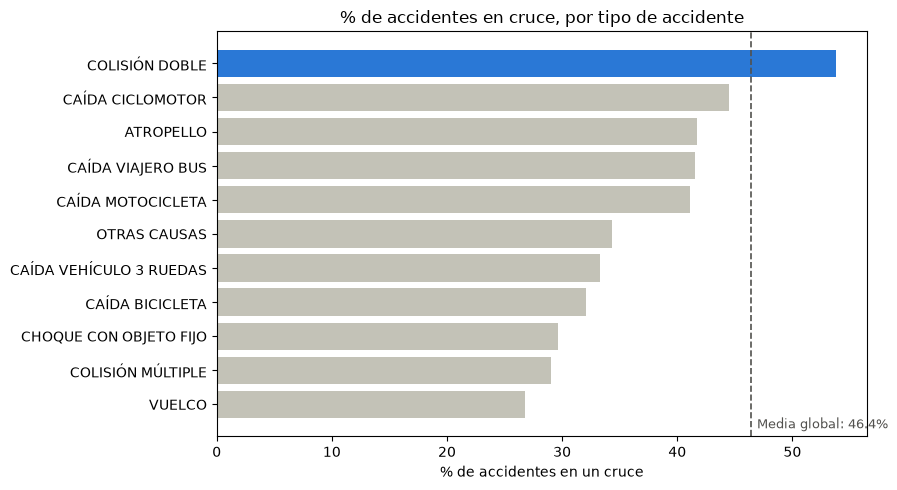

In [12]:
# Relación entre ES_CRUCE y TIPO ACCIDENTE

print('% de accidentes en cruce, por TIPO ACCIDENTE (ordenado):')
print((df_final.groupby('TIPO ACCIDENTE')['ES_CRUCE'].mean() * 100).round(1).sort_values(ascending=False))

tabla_cruce_tipoaccidente = (df_final.groupby('TIPO ACCIDENTE')['ES_CRUCE'].mean() * 100).round(1).sort_values()
media_global = df_final['ES_CRUCE'].mean() * 100

fig, ax = plt.subplots(figsize=(9, 5))
colores = ['#2a78d6' if v > media_global else '#c3c2b7' for v in tabla_cruce_tipoaccidente]
ax.barh(tabla_cruce_tipoaccidente.index, tabla_cruce_tipoaccidente.values, color=colores)
ax.axvline(media_global, color='#52514e', linestyle='--', linewidth=1.2)
ax.text(media_global + 0.5, -0.7, f'Media global: {media_global:.1f}%', fontsize=9, color='#52514e')
ax.set_xlabel('% de accidentes en un cruce')
ax.set_title('% de accidentes en cruce, por tipo de accidente')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '09_cruce_por_tipo_accidente.png', dpi=150, bbox_inches='tight')
plt.show()

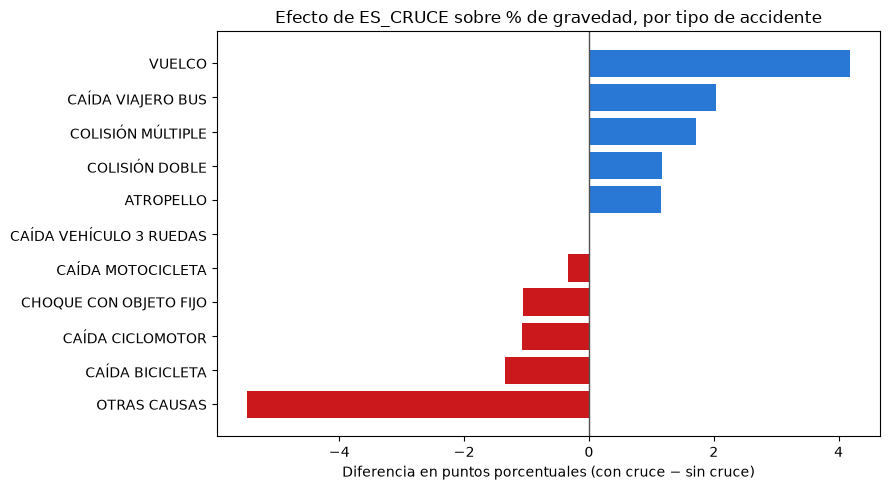

In [13]:
# Efecto de ES_CRUCE DENTRO de cada TIPO ACCIDENTE (para no mezclar composiciones distintas)
tabla_tipo_acc = df_final.groupby(['TIPO ACCIDENTE', 'ES_CRUCE'])['GRAVE'].mean().unstack() * 100
tabla_tipo_acc.columns = ['pct_grave_sin_cruce', 'pct_grave_con_cruce']
tabla_tipo_acc['diferencia_pts'] = (tabla_tipo_acc['pct_grave_con_cruce'] - tabla_tipo_acc['pct_grave_sin_cruce']).round(2)
tabla_tipo_acc.round(2).sort_values('diferencia_pts', ascending=False)

tabla_ordenada = tabla_tipo_acc.sort_values('diferencia_pts', ascending=True)
colores = ['#2a78d6' if v > 0 else '#cb181d' for v in tabla_ordenada['diferencia_pts']]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(tabla_ordenada.index, tabla_ordenada['diferencia_pts'], color=colores)
ax.axvline(0, color='#52514e', linewidth=1)
ax.set_xlabel('Diferencia en puntos porcentuales (con cruce − sin cruce)')
ax.set_title('Efecto de ES_CRUCE sobre % de gravedad, por tipo de accidente')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '10_diferencia_cruce_por_tipo.png', dpi=150, bbox_inches='tight')
plt.show()

En los dos tipos de accidente más frecuentes (colisión doble, 55% del total, y atropello, 15% del total — juntos, el 70% del dataset), el cruce aumenta la tasa de gravedad (+1.2 puntos en ambos), igual que en colisión múltiple (+1.7) y vuelco (+4.2, aunque con pocos casos). En categorías menos frecuentes (caída de bicicleta, ciclomotor, choque contra objeto fijo) el signo se invierte, pero son grupos mucho más pequeños y más sensibles al ruido muestral.

El punto clave no es que el efecto sea uniforme sino que el efecto marginal (0.32 puntos) es mucho más pequeño que los efectos dentro de cada tipo (de 1 a 4 puntos en las categorías grandes) porque, al mezclar todos los tipos de accidente en una sola comparación, la distinta composición de tipos entre cruces y no-cruces (más colisión doble en los cruces, más atropello fuera de ellos) diluye ese efecto real.

**Decisión:** conservo `ES_CRUCE` como variable, no por su efecto marginal (débil y engañoso si se mira aislado), sino porque su efecto real, condicionado al tipo de accidente y al tipo de vía, es más relevante que el efecto marginal, y ese es precisamente el tipo de variable de la que puede salir valor en feature engineering (p. ej. una interacción `TIPO_ACCIDENTE_x_CRUCE` o `TIPO_VIA_x_CRUCE`).

**Corrección sobre una versión anterior:** en una versión anterior de este notebook, calculaba `TIPO_VIA` solo sobre el tramo antes del guion, asumiendo (sin comprobarlo) que el primer tramo era el "principal". Al verificarlo con los datos, comprobé que esto no se sostiene:


In [14]:
# ¿El orden de los dos tramos en un cruce sigue algún criterio (p. ej. vía principal primero)?
cruces_texto = df_final.loc[df_final['ES_CRUCE'] == 1, 'LUGAR ACCIDENTE']
tramos = cruces_texto.str.split(' - ', n=1, expand=True)
orden_alfabetico = (tramos[0].str.strip() <= tramos[1].str.strip())

print(f'% de cruces cuyo orden de tramos es alfabético: {orden_alfabetico.mean()*100:.1f}%')

% de cruces cuyo orden de tramos es alfabético: 88.3%


El orden de los dos tramos es alfabético en ~88% de los casos — es una simple convención de cómo se registró el texto, no indica cuál de las dos vías es la "principal". Quedarse solo con el primer tramo, por tanto, no tiene ninguna base real y **descarta información relevante en algunos casos** (por ejemplo, pierde por completo que una de las vías es una autovía si esta aparece en segundo lugar). Lo corrijo usando todo el texto, con un orden de prioridad de tipos de vía (de mayor a menor velocidad/relevancia esperada) en vez de depender de la posición:


In [15]:
df_final = aplicar_tipo_via(df_final)
df_final['TIPO_VIA'].value_counts(dropna=False)

TIPO_VIA
CALLE        36180
AVENIDA      14158
PASEO         7287
AUTOVIA       5225
PLAZA         1550
GLORIETA      1293
OTROS         1284
CARRETERA     1216
RONDA          580
Name: count, dtype: int64

Esto es más consistente con el propio propósito de `TIPO_VIA`: capturar si el accidente ocurre en un entorno de mayor velocidad/riesgo estructural (autovía, carretera, ronda) independientemente de si esa vía aparece como primer o segundo tramo en el texto.

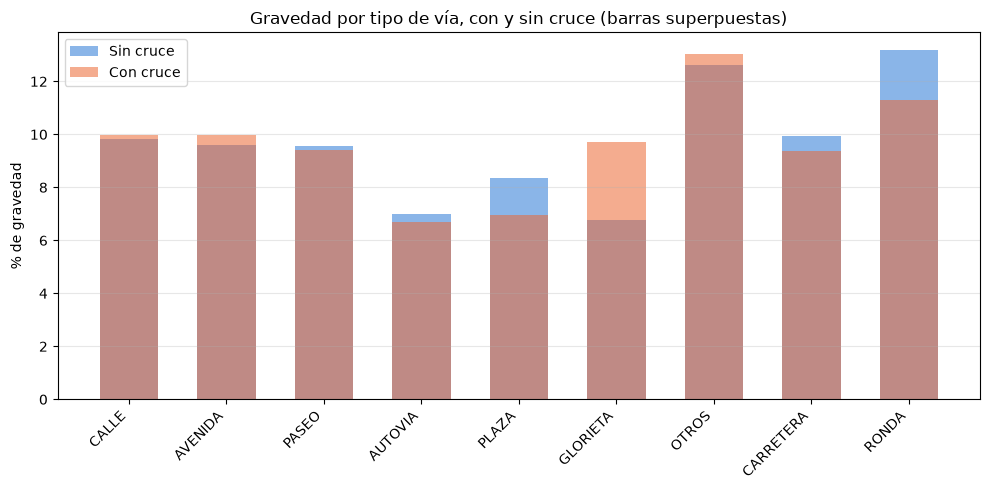

In [16]:
tabla_wide = df_final.groupby(['TIPO_VIA', 'ES_CRUCE'])['GRAVE'].mean() * 100
orden = df_final['TIPO_VIA'].value_counts().index  # de mayor a menor muestra total
sin_cruce = tabla_wide.xs(0, level='ES_CRUCE').reindex(orden)
con_cruce = tabla_wide.xs(1, level='ES_CRUCE').reindex(orden)

x = np.arange(len(orden))
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x, sin_cruce, width=0.6, label='Sin cruce', color='#2a78d6', alpha=0.55)
ax.bar(x, con_cruce, width=0.6, label='Con cruce', color='#eb6834', alpha=0.55)
ax.set_xticks(x)
ax.set_xticklabels(orden, rotation=45, ha='right')
ax.set_ylabel('% de gravedad')
ax.set_title('Gravedad por tipo de vía, con y sin cruce (barras superpuestas)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '11_gravedad_tipo_via_cruce_superpuesto.png', dpi=150, bbox_inches='tight')
plt.show()

En vías de tipo `GLORIETA` el cruce sí eleva notablemente la tasa de gravedad (6.8% sin cruce vs 9.7% con cruce), mientras que en `CALLE`, `AVENIDA` o `PASEO` apenas cambia, y en `CARRETERA` incluso baja ligeramente (9.96% → 9.38%). Esto confirma que `ES_CRUCE` **no es una variable de efecto único ni uniforme**, sino que su valor depende de la interacción con el tipo de vía — justo el tipo de patrón que interesa capturar de cara al feature engineering (ej. una variable combinada `TIPO_VIA_x_CRUCE`), en vez de esperar que actúe igual en todos los contextos.

> **Nota para feature engineering:** la clasificación de `TIPO_VIA` mediante reglas de texto es una primera aproximación razonable, pero es mejorable (p. ej. geocodificar `LUGAR ACCIDENTE` con `osmnx`/Nominatim para obtener coordenadas y cruzar con capas de velocidad de vía, como ya se explora en el EDA geográfico). Aquí dejo resuelto lo mínimo necesario para no descartar la columna de raíz ni el patrón de cruce.

## 4. Missing data

Recalculo los nulos **sobre el dataset ya a nivel accidente**, no sobre el crudo.


In [17]:
missing = df_final.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df_final) * 100).round(2)
pd.DataFrame({'n_nulos': missing, 'pct': missing_pct})

,n_nulos,pct


No quedan nulos relevantes a nivel accidente en las variables que se van a modelizar (las únicas columnas con nulos, si las hay, son residuales como `TIPO_VIA` u otras de texto libre que no se usarán directamente en el modelo). Regla que aplico, para dejar constancia por si el pipeline se re-ejecuta con datos nuevos que sí tengan huecos:

- **Categóricas:** imputar con la categoría explícita `"Desconocido"` (no eliminar filas) — coherente con que, en este dominio, el propio "no asignado" resultó ser informativo en el EDA (p. ej. en `SEXO` o `Tipo Vehiculo`).
- **Numéricas:** imputar con la mediana **calculada solo sobre el conjunto de entrenamiento** (ver Fase 6), nunca sobre el dataset completo, para evitar fuga de información del test.


In [18]:
df_final = imputar_categoricas_desconocido(df_final)
print('Nulos restantes en categóricas de modelo:', df_final[COLS_CATEGORICAS_MODELO].isna().sum().sum())

Nulos restantes en categóricas de modelo: 0


## 5. Variable numérica y outliers

`Nº VICTIMAS *` presenta una distribución muy asimétrica (la mayoría de accidentes tienen 1 víctima, con una cola larga de casos con varias). Antes de transformar, reviso los valores extremos para descartar que sean errores de captura.


In [19]:
print(df_final['Nº VICTIMAS *'].describe())
print()
print('Accidentes con 9 o más víctimas:')
print(df_final['Nº VICTIMAS *'].value_counts().sort_index().loc[lambda s: s.index >= 9])

count    68773.000000
mean         1.279092
std          0.721309
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         19.000000
Name: Nº VICTIMAS *, dtype: float64

Accidentes con 9 o más víctimas:
Nº VICTIMAS *
9     9
10    8
11    3
12    2
13    2
14    2
15    1
16    1
18    1
19    2
Name: count, dtype: int64


Los valores altos (hasta 19 víctimas) son poco frecuentes pero plausibles en accidentes reales de tráfico urbano con varios vehículos implicados (p. ej. colisiones múltiples o atropellos con varios heridos) — no detecto valores imposibles (negativos, cero, o desproporcionados sin explicación), así que **no los elimino como outliers**, los trato como cola larga real de la distribución. Añado una versión transformada en logaritmo, quedando ambas versiones disponibles para decidir en feature engineering / modelización.

In [20]:
df_final['N_VICTIMAS_LOG'] = np.log1p(df_final['Nº VICTIMAS *'])
df_final[['Nº VICTIMAS *', 'N_VICTIMAS_LOG']].describe()

,Nº VICTIMAS *,N_VICTIMAS_LOG
count,68773.000000,68773.000000
mean,1.279092,0.792485
std,0.721309,0.225994
min,1.000000,0.693147
25%,1.000000,0.693147
50%,1.000000,0.693147
75%,1.000000,0.693147
max,19.000000,2.995732


## 6. Train / test split

Separo el dataset antes de cualquier paso que dependa de estadísticos calculados sobre los datos (medias, medianas, encoders de frecuencia, etc.), para evitar fuga de información.

Al tratarse de una serie temporal de varios años (2012-2018 en el Excel original), valoro dos estrategias:

1. **Split temporal** (train: hasta el año de corte de `config/data.yaml`, test: posterior): más realista si el modelo se plantea como una herramienta que se entrenaría con histórico para predecir accidentes futuros. Tiene la ventaja añadida de que permite comprobar si el modelo generaliza a un año que no ha visto, con la tendencia temporal real (observo más abajo que la tasa de gravedad ha ido bajando año a año).
2. **Split aleatorio estratificado por `GRAVE`**: más estándar y con distribución de clases idéntica en train y test, útil si el objetivo del TFM es puramente comparar modelos sobre la misma distribución.

Genero **ambos** y dejo documentada la recomendación: usar el split temporal como validación principal (más honesto), y el estratificado como referencia secundaria para comparar métricas con la literatura o entre modelos.


In [21]:
print('Tasa de gravedad por año:')
print((df_final.groupby('AÑO')['GRAVE'].mean() * 100).round(2))

Tasa de gravedad por año:
AÑO
2012    10.23
2013    10.66
2014    10.87
2015     9.72
2016     9.13
2017     8.77
2018     8.19
Name: GRAVE, dtype: float64


In [22]:
# --- Split temporal (año de corte definido en config/data.yaml) ---
AÑO_CORTE = cfg.data['split_temporal']['anio_corte']
train_temporal, test_temporal = split_temporal(df_final, año_corte=AÑO_CORTE)

print('SPLIT TEMPORAL')
print(f'  Train ({train_temporal["AÑO"].min()}-{train_temporal["AÑO"].max()}): '
      f'{train_temporal.shape[0]:,} filas | {train_temporal["GRAVE"].mean()*100:.2f}% graves')
print(f'  Test  ({test_temporal["AÑO"].min()}-{test_temporal["AÑO"].max()}): '
      f'{test_temporal.shape[0]:,} filas | {test_temporal["GRAVE"].mean()*100:.2f}% graves')

SPLIT TEMPORAL
  Train (2012-2017): 58,095 filas | 9.86% graves
  Test  (2018-2018): 10,678 filas | 8.19% graves


In [23]:
# --- Split aleatorio estratificado (referencia secundaria; test_size en config/data.yaml) ---
TEST_SIZE = cfg.data['split_aleatorio']['test_size']
train_rand, test_rand = split_aleatorio_estratificado(df_final, test_size=TEST_SIZE, random_state=RANDOM_STATE)

print('SPLIT ALEATORIO ESTRATIFICADO')
print(f'  Train: {train_rand.shape[0]:,} filas | {train_rand["GRAVE"].mean()*100:.2f}% graves')
print(f'  Test:  {test_rand.shape[0]:,} filas | {test_rand["GRAVE"].mean()*100:.2f}% graves')

SPLIT ALEATORIO ESTRATIFICADO
  Train: 55,018 filas | 9.60% graves
  Test:  13,755 filas | 9.60% graves


Sobre el desbalanceo de clases (~9.6% graves): **no lo corrijo en el preprocessing** (ni con SMOTE ni con submuestreo). Es una decisión de modelización, no de preprocesado — lo aplicaré, si procede, únicamente sobre `train`, nunca sobre `test`, tal y como ya se apuntaba en las conclusiones del EDA.

## 7. Control de calidad final y guardado

Tabla resumen de todo el proceso, de principio a fin, y guardado de los artefactos para el siguiente notebook.


In [24]:
resumen = pd.DataFrame({
    'Paso': [
        'Registros originales (nivel persona)',
        'Tras excluir TESTIGO',
        'Tras eliminar duplicados exactos',
        'Tras eliminar LESIVIDAD no asignada',
        'Accidentes únicos (nivel accidente, dataset final)',
    ],
    'Filas': [
        n_original,
        n_sin_testigos,
        n_sin_duplicados,
        len(df_pers),
        len(df_final),
    ]
})
resumen

,Paso,Filas
0,Registros originales (nivel persona),199078
1,Tras excluir TESTIGO,174353
2,Tras eliminar duplicados exactos,170288
3,Tras eliminar LESIVIDAD no asignada,163853
4,"Accidentes únicos (nivel accidente, dataset fi...",68773


In [25]:
print('Dimensiones finales:', df_final.shape)
print('Columnas:', list(df_final.columns))
print()
print('Duplicados en Nº PARTE (debe ser 0):', df_final['Nº PARTE'].duplicated().sum())
print('Nulos en la variable target GRAVE (debe ser 0):', df_final['GRAVE'].isna().sum())

Dimensiones finales: (68773, 33)
Columnas: ['Nº PARTE', 'FECHA', 'AÑO', 'MES', 'RANGO HORARIO', 'DIA SEMANA', 'DISTRITO', 'LUGAR ACCIDENTE', 'TIPO ACCIDENTE', 'Nº VICTIMAS *', 'CPFA Granizo', 'CPFA Hielo', 'CPFA Lluvia', 'CPFA Niebla', 'CPFA Seco', 'CPFA Nieve', 'CPSV Mojada', 'CPSV Aceite', 'CPSV Barro', 'CPSV Grava Suelta', 'CPSV Hielo', 'CPSV Seca Y Limpia', 'GRAVE', 'INCLUYE_PEATON', 'INCLUYE_MOTO', 'INCLUYE_BICI', 'INCLUYE_EDAD_RIESGO', 'N_PERSONAS_IMPLICADAS', 'HORA', 'ES_FINDE', 'ES_CRUCE', 'TIPO_VIA', 'N_VICTIMAS_LOG']

Duplicados en Nº PARTE (debe ser 0): 0
Nulos en la variable target GRAVE (debe ser 0): 0


In [26]:
df_final.to_csv(PROCESSED_DIR / 'accidentes_accidente_nivel_clean.csv', index=False)
train_temporal.to_csv(PROCESSED_DIR / 'train_temporal.csv', index=False)
test_temporal.to_csv(PROCESSED_DIR / 'test_temporal.csv', index=False)
train_rand.to_csv(PROCESSED_DIR / 'train_random.csv', index=False)
test_rand.to_csv(PROCESSED_DIR / 'test_random.csv', index=False)

# Dataset a nivel persona ya limpio, por si feature engineering necesita
# construir variables más finas de agregación (proporciones, edad media, etc.)
df_pers.to_csv(PROCESSED_DIR / 'personas_clean.csv', index=False)

print(f'Ficheros guardados en {PROCESSED_DIR}')

Ficheros guardados en C:\Users\U1096722\TFM-accidentes-trafico\data\processed


## Resumen de decisiones tomadas en este notebook

| # | Decisión |
|---|----------|
| 1 | Corrijo una inconsistencia de encoding en `Tramo Edad` (`ANOS` → `AÑOS`) antes de cualquier mapeo de categorías |
| 2 | Calculo los duplicados exactos **tras** excluir testigos, no antes (el número cambia según el orden) |
| 3 | El target (`GRAVE`) se construye a **nivel accidente** como máximo de la gravedad de las personas implicadas, verificando antes que ningún accidente se pierde por completo al filtrar `LESIVIDAD` nula (con aviso automático en código si algún día sí se pierde alguno) |
| 4 | Las variables de persona más predictivas según el EDA (tipo de persona, tipo de vehículo, tramo de edad) las preservo como *flags* de implicación a nivel accidente, en vez de perderse en la agregación |
| 5 | Verifico explícitamente que las columnas "de accidente" (fecha, distrito, meteorología, etc.) son realmente invariantes dentro de cada `Nº PARTE` antes de asumirlo |
| 6 | `RANGO HORARIO` y `LUGAR ACCIDENTE` (texto libre de alta cardinalidad) las transformo en variables utilizables (`HORA` numérica, `TIPO_VIA`) |
| 7 | Detecto y conservo el patrón de **intersección** en `LUGAR ACCIDENTE` (`ES_CRUCE`, ~46% de los accidentes); su efecto marginal es débil pero muestra interacción real con `TIPO_VIA` y `TIPO ACCIDENTE`, así que lo preservo para feature engineering en vez de descartarlo |
| 8 | Los nulos residuales en categóricas los imputo como categoría explícita `"Desconocido"`, no elimino filas |
| 9 | `Nº VICTIMAS *` no lo trato como outlier (los valores altos son accidentes reales con varios implicados); añado versión log-transformada sin eliminar la original |
| 10 | El split train/test se hace **antes** de cualquier imputación estadística o encoding, con dos estrategias documentadas (temporal y aleatorio estratificado) |
| 11 | El desbalanceo de clases lo dejo explícitamente para la fase de modelización, no lo corrijo aquí |
| 12 | El Excel de entrada lo valido contra un esquema mínimo de columnas nada más cargarlo, para fallar rápido y con un mensaje claro si se usa un Excel con formato distinto |
| 13 | Rutas de entrada/salida y parámetros de split (año de corte, `test_size`) los leo de `config/data.yaml` / `config/paths.yaml`, no los hardcodeo, manteniendo una única fuente de verdad con el resto del proyecto (incluido `pipeline_produccion.py`) |

**Siguiente paso:** `03_Feature_Engineering.ipynb`, partiendo de `train_temporal.csv` / `test_temporal.csv`